In [1]:
import torch
import torchvision
from torch import nn
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    torchvision.transforms.ToTensor(),
    transforms.Grayscale(),
    transforms.Resize((32, 32))
])

data = torchvision.datasets.MNIST(root = './data/', download = True, train = True, transform = transform)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 36174276.76it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1115111.65it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 9415358.33it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 2706041.02it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



torch.Size([1, 32, 32])


/opt/conda/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


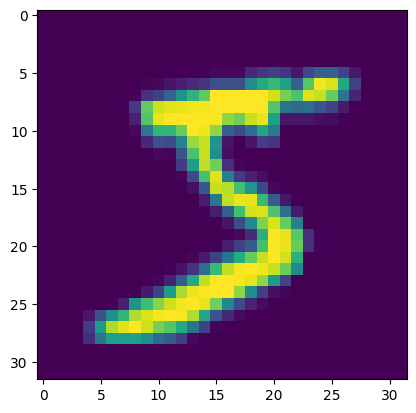

In [3]:
image, label = data[0]
print(image.shape)
plt.imshow(image.permute(1, 2, 0))

In [4]:
class DownsampleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, d_model):
        super(DownsampleBlock, self).__init__()
        self.in_channel = in_ch
        self.out_channel = out_ch
        self.d_model = d_model

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1)
            )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        self.mp2d = nn.MaxPool2d(kernel_size=2, stride=2)
        self.linear = nn.Sequential(
            nn.Linear(d_model, out_ch),
            nn.SiLU()
        )
        self.act = nn.SiLU()

    def forward(self, x, t):
        """
        x: (bs, in_ch, h, w)
        t: (bs, d_model)
        """
        t = self.linear(t) # (bs, d_model) => (bs, out_ch)
        t = t.unsqueeze(-1).unsqueeze(-1) # (bs, out_ch) => (bs, out_ch, 1, 1)


        x = self.conv1(x)  # (bs, in_ch, h, w) => (bs, out_ch, h, w)

        x = self.conv2(x)  # (bs, out_ch, h, w) => (bs, out_ch, h, w)
        x = x + t

        x = self.act(x)

        x = self.mp2d(x) # (bs, out_ch, h, w) => (bs, out_ch, h/2, w/2)

        return x

net = DownsampleBlock(in_ch=64, out_ch=128, d_model = 64)

x = torch.rand(size=(2, 64, 32, 32))
t = torch.rand(size=(2, 64))

print(net(x, t).shape)

torch.Size([2, 128, 16, 16])


In [5]:
class UpsampleBlock(nn.Module):
  def __init__(self, in_ch, out_ch, d_model):
    super(UpsampleBlock, self).__init__()
    self.in_channel = in_ch
    self.out_channel = out_ch
    self.d_model = d_model

    self.conv1 = nn.Sequential(
        nn.ConvTranspose2d(in_channels=in_ch, out_channels=out_ch, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Dropout(0.1)
    )

    self.conv2 = nn.Sequential(
        nn.Conv2d(in_channels=2*out_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

    self.linear = nn.Sequential(
        nn.Linear(d_model, out_ch),
        nn.SiLU()
    )

    self.act = nn.SiLU()

  def forward(self, x, op_x, t):
    t = self.linear(t).unsqueeze(-1).unsqueeze(-1)
    x = self.conv1(x)
    x = torch.cat((op_x, x), dim=1)
    x = self.conv2(x)
    x = x + t
    return x

net = UpsampleBlock(in_ch=1024, out_ch=512, d_model=64)
x = torch.rand(size=(2, 1024, 2, 2))
op_x = torch.rand(2, 512, 4, 4)
t = torch.rand(2, 64)

print(net(x, op_x, t).shape)




torch.Size([2, 512, 4, 4])


In [6]:

class UnetDiffusion(nn.Module):
  def __init__(
      self,
      beta_start=1e-4,
      beta_end=1e-1,
      time_steps=100,
      d_model=64,
      down=[64, 128, 256, 512, 1024],
      up=[1024, 512, 256, 128, 64],
      device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  ):
    super(UnetDiffusion, self).__init__()
    self.beta_start = beta_start
    self.beta_end = beta_end
    self.time_steps = time_steps
    self.d_model = d_model
    self.down = down
    self.up = up

    self.list_beta = torch.linspace(start=beta_start, end=beta_end, steps=time_steps).to(device)
    self.list_alpha = 1. - self.list_beta
    self.cumprod_alpha = torch.cumprod(self.list_alpha, dim=0).to(device)
    self.sqrt_cumprod_alpha = torch.sqrt(self.cumprod_alpha).to(device)
    self.sqrt_one_cumprod_alpha = torch.sqrt(1. - self.cumprod_alpha).to(device)


    self.time_embedding = nn.Embedding(time_steps, d_model)

    self.conv2d_input = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True)
    )
    self.encoder = nn.ModuleList([
        DownsampleBlock(in_ch=down[i], out_ch=down[i+1], d_model=d_model) for i in range(len(down)-1)
    ])

    self.bottle_neck = nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, stride=1, padding=1)

    self.decoder = nn.ModuleList([
        UpsampleBlock(in_ch=up[i], out_ch=up[i+1], d_model=d_model) for i in range(len(up) - 1)
    ])

    self.conv2d_output = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(1),
        nn.ReLU(inplace=True)
    )

  def forward_process(self, x: torch.Tensor, list_t: torch.Tensor):
    """
    x: origin image: (bs, c, h, w)
    list_t: list time step (bs,)

    return: list image at time steps: (bs, c, h, w), noise added: (bs, c, h, w)
    """
    list_sqrt_cumprod_alpha = self.sqrt_cumprod_alpha[list_t].to(x.device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
    list_sqrt_one_cumprod_alpha = self.sqrt_one_cumprod_alpha[list_t].to(x.device).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

    noise = torch.rand_like(x).to(x.device)

    out = x*list_sqrt_cumprod_alpha + noise*list_sqrt_one_cumprod_alpha

    return out.to(x.device), noise.to(x.device)

  def forward(self, x: torch.Tensor, t: torch.Tensor):
    """
    x: image added noise: (bs, c, h, w) = (bs, 1, 32, 32)
    list_t: list time step (bs,)

    return: predict_noise: (bs, c, h, w)
    """

    time_embedding = self.time_embedding(t).float() #(bs, d_model)

    input = self.conv2d_input(x) #(bs, 64, 32, 32)

    encoder_list = []
    encoder_list.append(input)
    for net in self.encoder:
      input = net(input, time_embedding)
      encoder_list.append(input)
    
    midle = encoder_list[-1] 
    out = self.bottle_neck(midle)

    for net in self.decoder: 
      encoder_list = encoder_list[:-1]
      out = net(out, encoder_list[-1], time_embedding)
      
    out = self.conv2d_output(out)

    return out 
  
  def reverse_process(self, x: torch.Tensor, t: torch.Tensor): 
    """
    x: 1 image with noise added (1, 1, 32, 32)
    t: time (1)
    """
    for i in range(t, 0, -1):
      x = 1./torch.sqrt(self.list_alpha[t])*(x - self.list_beta[t] * self.forward(x, t)/self.sqrt_one_cumprod_alpha[t]) + torch.sqrt((1. - self.cumprod_alpha[t - 1])*self.list_beta[t]/(1. - self.cumprod_alpha[t]))*torch.rand_like(x)
    
    t = torch.tensor([0], dtype=torch.int)
    x = 1./torch.sqrt(self.list_alpha[t])*(x - self.list_beta[t] * self.forward(x, t)/self.sqrt_one_cumprod_alpha[t])
    return x

      


In [7]:
def train_epoch(epoch, model: UnetDiffusion, loader, loss_func, optimizer, device):
  model.train()
  running_loss = 0.0
  reporting_steps = 100

  for i, (image, label) in enumerate(loader):
    image = image.to(device)
    batch_size = image.shape[0]
    time = torch.randint(low=0, high=100, size=(batch_size,), device=device)

    noise_image, real_noise = model.forward_process(image, time)
    noise_image = noise_image.to(device)
    real_noise = real_noise.to(device)
    noise_predict = model(noise_image, time).to(device)

    
    loss = loss_func(noise_predict, real_noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if i % reporting_steps == 0:
      print(f"Epoch {epoch} step {i} ave loss {running_loss/reporting_steps: .4f}")
      running_loss = 0.0
  

In [8]:
train_loader = DataLoader(data, batch_size=64, shuffle=True)
device = torch.device("cuda")
model = UnetDiffusion().to(device)
epochs = 200 
loss_function = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)


for epoch in range(epochs): 
  train_epoch(epoch=epoch, model=model, loader=train_loader, loss_func=loss_function, optimizer=optimizer, device=device)

torch.save(model.state_dict(), "/kaggle/working/diffusion.pth")

Epoch 0 step 0 ave loss  0.0044
Epoch 0 step 100 ave loss  0.0787
Epoch 0 step 200 ave loss  0.0371
Epoch 0 step 300 ave loss  0.0269
Epoch 0 step 400 ave loss  0.0227
Epoch 0 step 500 ave loss  0.0193
Epoch 0 step 600 ave loss  0.0170
Epoch 0 step 700 ave loss  0.0154
Epoch 0 step 800 ave loss  0.0137
Epoch 0 step 900 ave loss  0.0125
Epoch 1 step 0 ave loss  0.0001
Epoch 1 step 100 ave loss  0.0111
Epoch 1 step 200 ave loss  0.0104
Epoch 1 step 300 ave loss  0.0095
Epoch 1 step 400 ave loss  0.0092
Epoch 1 step 500 ave loss  0.0089
Epoch 1 step 600 ave loss  0.0084
Epoch 1 step 700 ave loss  0.0078
Epoch 1 step 800 ave loss  0.0077
Epoch 1 step 900 ave loss  0.0074
Epoch 2 step 0 ave loss  0.0001
Epoch 2 step 100 ave loss  0.0072
Epoch 2 step 200 ave loss  0.0071
Epoch 2 step 300 ave loss  0.0068
Epoch 2 step 400 ave loss  0.0065
Epoch 2 step 500 ave loss  0.0064
Epoch 2 step 600 ave loss  0.0061
Epoch 2 step 700 ave loss  0.0062
Epoch 2 step 800 ave loss  0.0057
Epoch 2 step 900 ave